# Customer Segmentation Kartu Kredit dengan K-Means Clustering
## Project Data Science — Metodologi CRISP-DM

**Nama:** Hegar Pancawala Radji
**NPM:** 50423581
**Mata Kuliah:** Data Science - Pertemuan 4


## 1. Business Understanding

### 1.1 Latar Belakang
Sebuah bank memiliki ribuan nasabah pemegang kartu kredit dengan karakteristik dan perilaku transaksi yang sangat beragam. Selama ini, bank memperlakukan seluruh nasabah dengan pendekatan pemasaran dan retensi yang seragam (*one-size-fits-all*), padahal kebutuhan dan potensi setiap nasabah berbeda-beda. Hal ini menyebabkan program promosi, penawaran produk, dan strategi retensi menjadi kurang efektif serta boros biaya.

### 1.2 Tujuan Bisnis (Business Objective)
Mengelompokkan (*clustering*) nasabah kartu kredit ke dalam beberapa segmen berdasarkan karakteristik demografis dan pola penggunaan kartu kredit, sehingga bank dapat:
- Merancang strategi pemasaran (*targeted marketing*) yang lebih tepat sasaran untuk setiap segmen.
- Mengidentifikasi segmen nasabah bernilai tinggi (*high value customer*) untuk program loyalitas.
- Mengidentifikasi segmen nasabah berisiko rendah aktivitas (potensi churn) agar dapat diberikan program retensi lebih dini.
- Mengoptimalkan alokasi limit kredit dan penawaran produk sesuai profil segmen.

### 1.3 Tujuan Data Mining (Data Mining Objective)
Membangun model **unsupervised learning (K-Means Clustering)** yang mampu mengelompokkan nasabah ke dalam sejumlah cluster optimal berdasarkan fitur numerik seperti usia, lama menjadi nasabah, limit kredit, saldo bergulir (*revolving balance*), jumlah transaksi, dan rasio utilisasi kartu kredit.

### 1.4 Kriteria Keberhasilan
- Model clustering menghasilkan **Silhouette Score** yang layak (idealnya > 0.3) sebagai indikasi cluster yang cukup terpisah.
- Setiap cluster yang terbentuk dapat **diinterpretasikan secara bisnis** (memiliki karakteristik/profil yang jelas dan berbeda satu sama lain).
- Model dapat **di-deploy** menjadi aplikasi sederhana (Streamlit) yang memungkinkan pengguna baru memasukkan data nasabah dan langsung mengetahui nasabah tersebut masuk ke segmen mana.


## 2. Data Understanding

### 2.1 Sumber Dataset
Dataset yang digunakan adalah **Credit Card Customers (BankChurners.csv)**, yang tersedia secara publik di Kaggle:
> Sumber: https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers

Dataset ini berisi data 10.127 nasabah kartu kredit sebuah bank beserta atribut demografis dan perilaku transaksi selama beberapa bulan terakhir.

### 2.2 Alasan Dataset Sesuai untuk Clustering
- Dataset bersifat **tabular (.csv)** dengan **10.127 baris dan 23 kolom** (jauh melebihi syarat minimal 1.000 baris dan 8 kolom).
- Memiliki lebih dari 10 **fitur numerik** (usia, lama menjadi nasabah, limit kredit, saldo bergulir, jumlah transaksi, dsb) — jauh melebihi syarat minimal 3 fitur numerik.
- Fitur-fitur numeriknya secara alami **merepresentasikan perilaku finansial nasabah**, sehingga sangat memungkinkan untuk dikelompokkan menjadi beberapa segmen nasabah yang berbeda (misalnya: nasabah baru vs lama, nasabah dengan aktivitas tinggi vs rendah, nasabah dengan risiko utilisasi tinggi vs rendah).


In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import joblib
import json
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


In [ ]:
# Membaca dataset
df = pd.read_csv("BankChurners.csv")
df.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
# Dimensi dataset
print("Jumlah baris dan kolom:", df.shape)


Jumlah baris dan kolom: (10127, 23)


In [ ]:
# Informasi struktur data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:
# Cek missing value dan data duplikat
print("Jumlah missing value per kolom:")
print(df.isnull().sum())

print("\nJumlah data duplikat:", df.duplicated().sum())


Jumlah missing value per kolom:
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category 

Dataset **tidak memiliki missing value maupun data duplikat**, sehingga siap digunakan tanpa proses imputasi.

In [ ]:
# Statistik deskriptif fitur numerik
df.describe().T


,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,7.080821e+08,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1.438300e+03,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.000000e+00,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.000000e+00,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


In [ ]:
# Distribusi status nasabah (hanya untuk pemahaman data, TIDAK digunakan sebagai fitur clustering
# karena clustering bersifat unsupervised)
df["Attrition_Flag"].value_counts()


,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


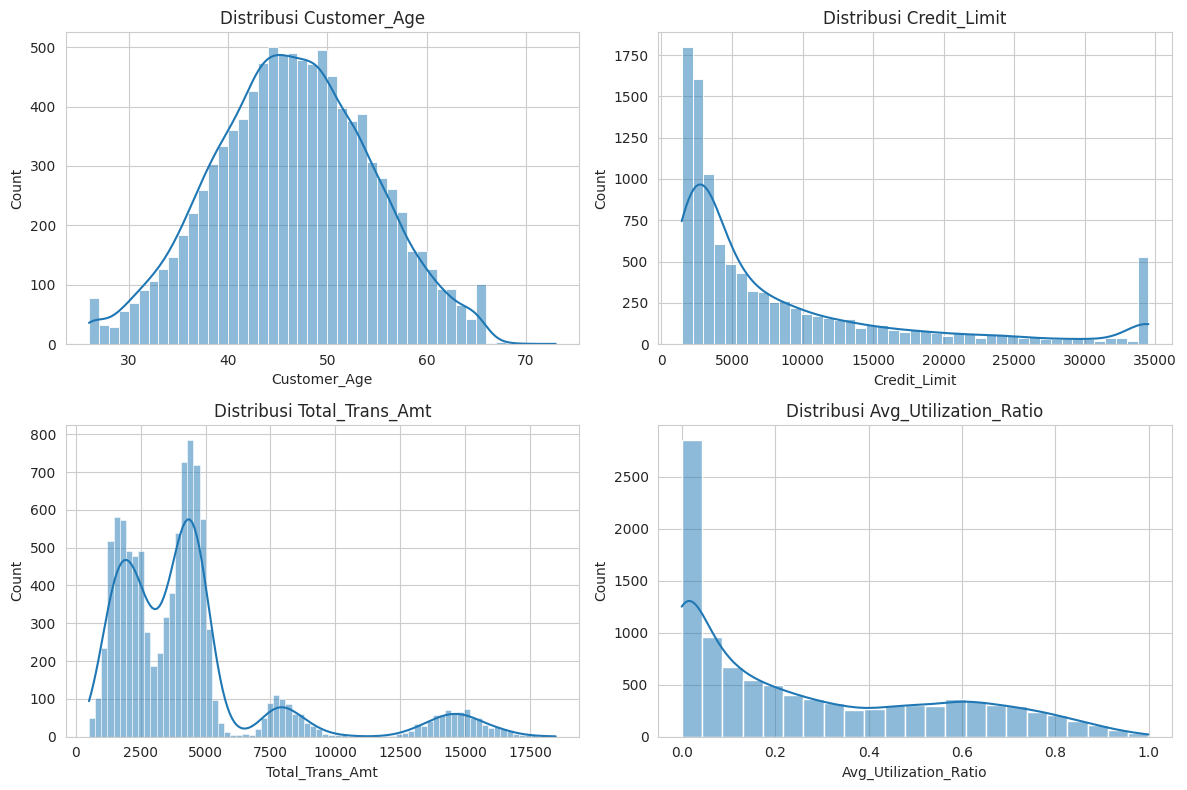

In [ ]:
# Visualisasi distribusi beberapa fitur numerik kunci
fitur_eksplorasi = ["Customer_Age", "Credit_Limit", "Total_Trans_Amt", "Avg_Utilization_Ratio"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(fitur_eksplorasi):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribusi {col}")

plt.tight_layout()
plt.show()


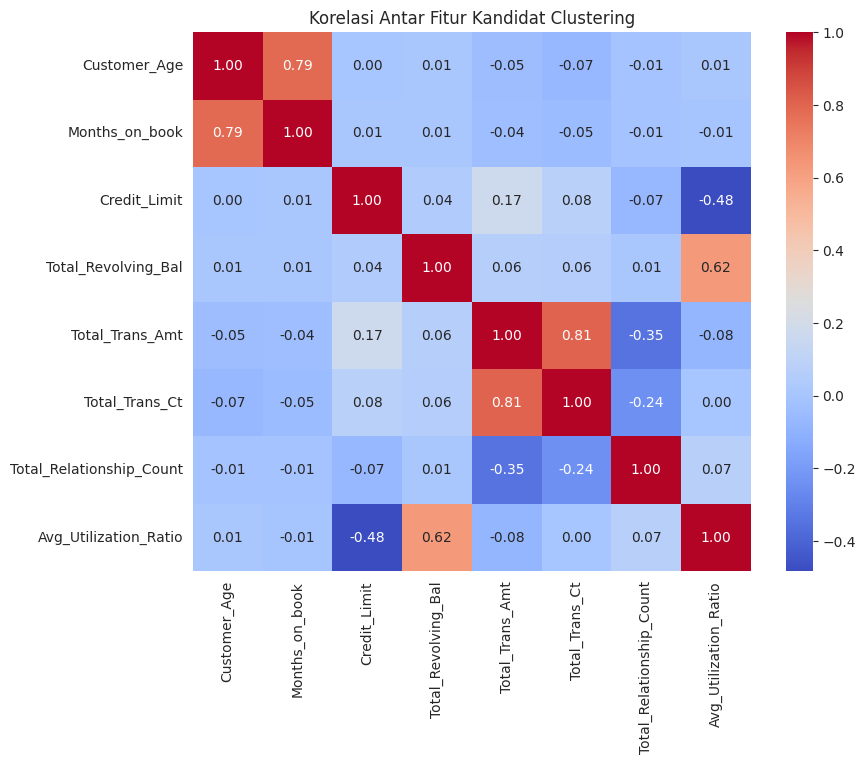

In [ ]:
# Korelasi antar fitur numerik yang akan dipertimbangkan untuk clustering
fitur_kandidat = [
    "Customer_Age", "Months_on_book", "Credit_Limit", "Total_Revolving_Bal",
    "Total_Trans_Amt", "Total_Trans_Ct", "Total_Relationship_Count", "Avg_Utilization_Ratio"
]

plt.figure(figsize=(9, 7))
sns.heatmap(df[fitur_kandidat].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Fitur Kandidat Clustering")
plt.show()


Dari heatmap korelasi, tidak ditemukan pasangan fitur dengan korelasi yang sangat ekstrem (>0.9) sehingga seluruh fitur kandidat cukup layak digunakan bersama-sama untuk clustering tanpa masalah multikolinearitas yang parah.

## 3. Data Preparation

### 3.1 Pembersihan Kolom
Beberapa kolom perlu dihapus sebelum dilakukan clustering:
- `CLIENTNUM`: hanya nomor identitas nasabah, bukan atribut perilaku sehingga tidak relevan untuk clustering.
- Dua kolom terakhir yang diawali `Naive_Bayes_Classifier_...`: merupakan hasil (output) dari model klasifikasi Naive Bayes yang sudah pernah dibuat oleh pembuat dataset. Kolom ini **direkomendasikan untuk dihapus** karena bukan bagian dari data mentah dan dapat menyebabkan *data leakage*.
- `Attrition_Flag` dan kolom kategorikal lain (`Gender`, `Education_Level`, `Marital_Status`, `Income_Category`, `Card_Category`) tidak digunakan sebagai fitur clustering pada model utama, karena clustering di sini difokuskan pada **fitur numerik perilaku transaksi** sesuai ketentuan tugas (minimal 3 fitur numerik).


In [ ]:
# Hapus kolom ID dan kolom hasil model Naive Bayes yang bocor (data leakage)
kolom_dibuang = ["CLIENTNUM"] + [c for c in df.columns if c.startswith("Naive_Bayes_Classifier")]

df_clean = df.drop(columns=kolom_dibuang)
print("Kolom yang dihapus:", kolom_dibuang)
print("Shape setelah pembersihan kolom:", df_clean.shape)


Kolom yang dihapus: ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
Shape setelah pembersihan kolom: (10127, 20)


### 3.2 Pemilihan Fitur untuk Clustering

Fitur numerik yang dipilih untuk clustering merepresentasikan tiga aspek utama perilaku nasabah:
1. **Profil nasabah**: `Customer_Age`, `Months_on_book`
2. **Kapasitas & penggunaan kredit**: `Credit_Limit`, `Total_Revolving_Bal`, `Avg_Utilization_Ratio`
3. **Aktivitas transaksi**: `Total_Trans_Amt`, `Total_Trans_Ct`, `Total_Relationship_Count`


In [ ]:
# Fitur numerik yang digunakan untuk clustering
features = [
    "Customer_Age",
    "Months_on_book",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Relationship_Count",
    "Avg_Utilization_Ratio"
]

X = df_clean[features].copy()
X.head()


,Customer_Age,Months_on_book,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Avg_Utilization_Ratio
0,45,39,12691.0,777,1144,42,5,0.061
1,49,44,8256.0,864,1291,33,6,0.105
2,51,36,3418.0,0,1887,20,4,0.000
3,40,34,3313.0,2517,1171,20,3,0.760
4,40,21,4716.0,0,816,28,5,0.000


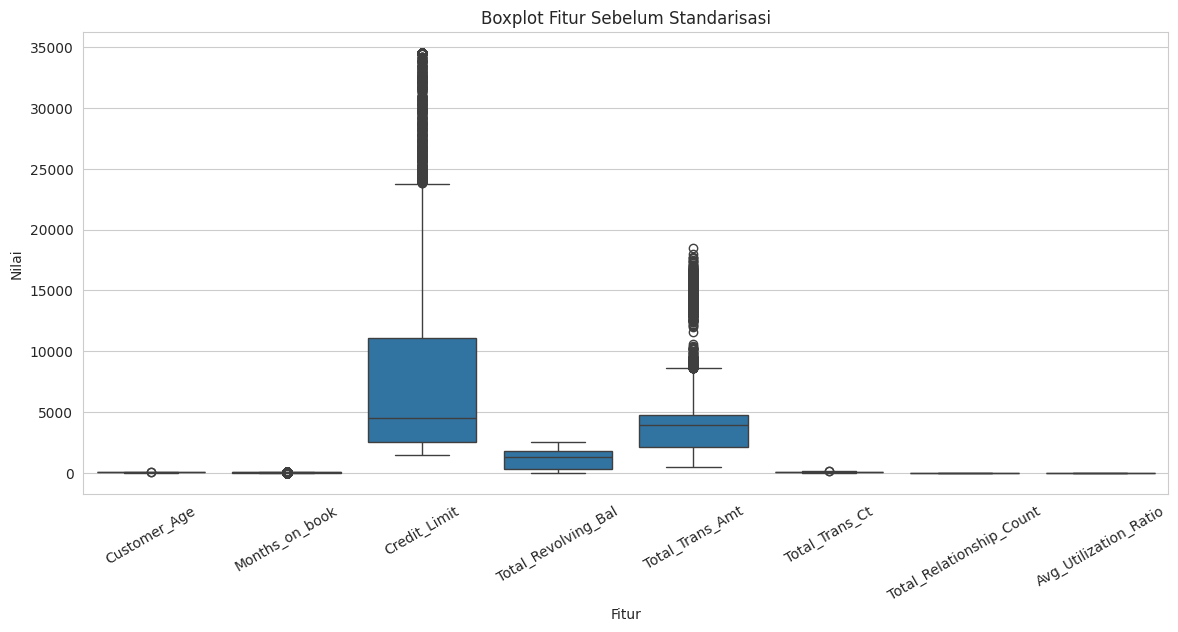

In [ ]:
# Cek outlier menggunakan boxplot
plt.figure(figsize=(14, 6))
X_melt = X.melt(var_name="Fitur", value_name="Nilai")
sns.boxplot(data=X_melt, x="Fitur", y="Nilai")
plt.xticks(rotation=30)
plt.title("Boxplot Fitur Sebelum Standarisasi")
plt.show()


Beberapa fitur seperti `Credit_Limit` dan `Total_Trans_Amt` memiliki outlier di sisi atas (nasabah dengan limit/transaksi sangat tinggi). Nilai-nilai ini **tetap dipertahankan** karena bukan merupakan data error, melainkan representasi nasabah kelas atas (*premium customer*) yang justru penting untuk diidentifikasi sebagai segmen tersendiri.

In [ ]:
# Standarisasi fitur (StandardScaler) agar setiap fitur memiliki skala yang setara
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape data setelah standarisasi:", X_scaled.shape)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()


Shape data setelah standarisasi: (10127, 8)


,Customer_Age,Months_on_book,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Avg_Utilization_Ratio
0,-0.165406,0.384621,0.446622,-0.473422,-0.959707,-0.973895,0.763943,-0.775882
1,0.333570,1.010715,-0.041367,-0.366667,-0.916433,-1.357340,1.407306,-0.616276
2,0.583058,0.008965,-0.573698,-1.426858,-0.740982,-1.911206,0.120579,-0.997155
3,-0.789126,-0.241473,-0.585251,1.661686,-0.951758,-1.911206,-0.522785,1.759686
4,-0.789126,-1.869317,-0.430877,-1.426858,-1.056263,-1.570365,0.763943,-0.997155


## 4. Modeling

### 4.1 Menentukan Jumlah Cluster Optimal
Digunakan dua pendekatan untuk menentukan jumlah cluster (k) terbaik: **Elbow Method** (berdasarkan inertia) dan **Silhouette Score**.


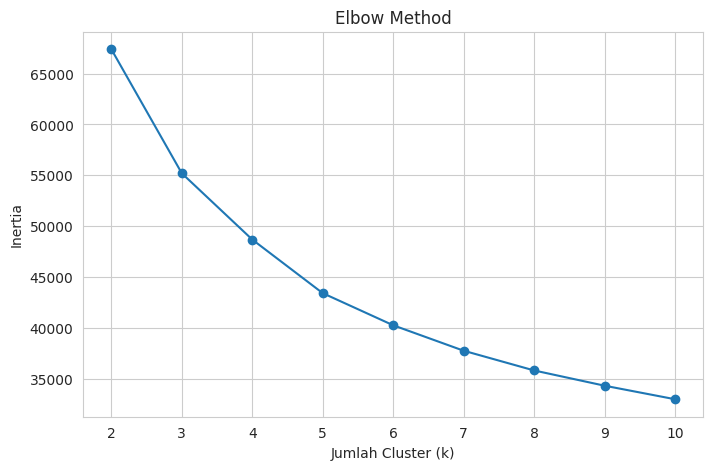

In [ ]:
# Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


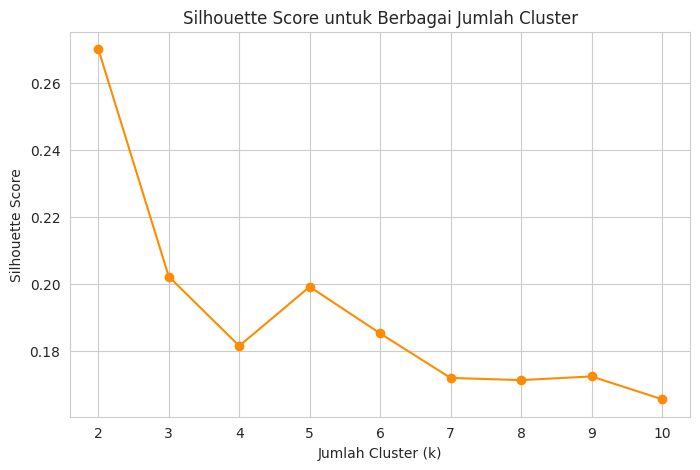

In [ ]:
# Silhouette Score untuk beberapa jumlah cluster
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Berbagai Jumlah Cluster")
plt.show()


In [ ]:
# Menentukan k terbaik berdasarkan Silhouette Score tertinggi
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]

print("Jumlah cluster terbaik (k):", best_k)
print("Silhouette Score terbaik:", max(silhouette_scores))


Jumlah cluster terbaik (k): 2
Silhouette Score terbaik: 0.2701724715834183


In [ ]:
# Melatih model K-Means final dengan jumlah cluster terbaik
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clean["Cluster"] = cluster_labels
df_clean[features + ["Cluster"]].head()


,Customer_Age,Months_on_book,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Avg_Utilization_Ratio,Cluster
0,45,39,12691.0,777,1144,42,5,0.061,0
1,49,44,8256.0,864,1291,33,6,0.105,0
2,51,36,3418.0,0,1887,20,4,0.000,0
3,40,34,3313.0,2517,1171,20,3,0.760,0
4,40,21,4716.0,0,816,28,5,0.000,0


## 5. Evaluation

### 5.1 Metrik Evaluasi Clustering


In [ ]:
# Evaluasi menggunakan Silhouette Score dan Davies-Bouldin Index
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_db_index = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Silhouette Score : {final_silhouette:.4f}")
print(f"Davies-Bouldin Index : {final_db_index:.4f}")


Silhouette Score : 0.2702
Davies-Bouldin Index : 1.5015


Cluster
0    8708
1    1419
Name: count, dtype: int64


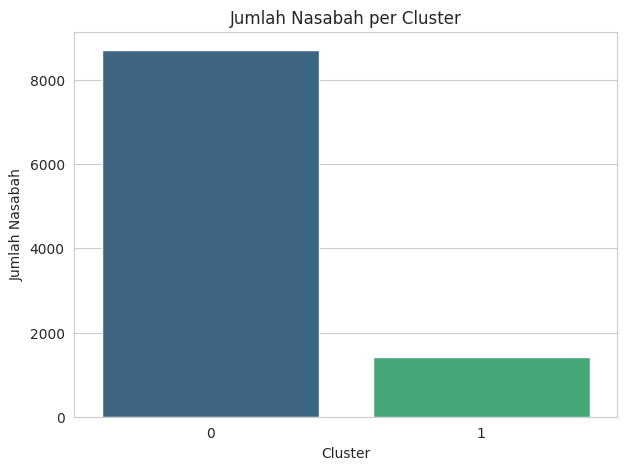

In [ ]:
# Jumlah nasabah pada setiap cluster
cluster_counts = df_clean["Cluster"].value_counts().sort_index()
print(cluster_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Nasabah")
plt.title("Jumlah Nasabah per Cluster")
plt.show()


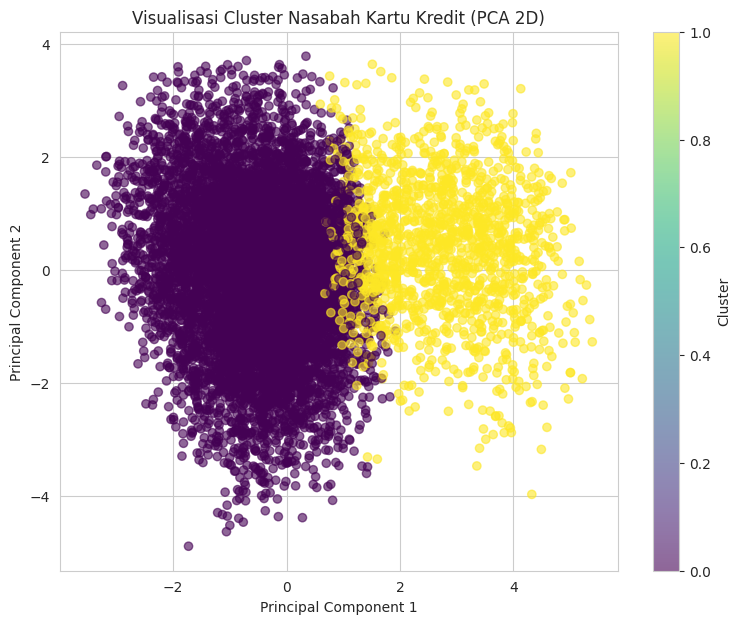

Total variansi yang dijelaskan oleh 2 komponen PCA: 48.27%


In [ ]:
# Visualisasi cluster menggunakan PCA (reduksi ke 2 dimensi untuk keperluan plotting)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Visualisasi Cluster Nasabah Kartu Kredit (PCA 2D)")
plt.colorbar(scatter, label="Cluster")
plt.show()

print(f"Total variansi yang dijelaskan oleh 2 komponen PCA: {pca.explained_variance_ratio_.sum()*100:.2f}%")


In [ ]:
# Profil rata-rata setiap cluster (interpretasi bisnis)
cluster_profile = df_clean.groupby("Cluster")[features].mean().round(2)
cluster_profile["Jumlah_Nasabah"] = df_clean["Cluster"].value_counts().sort_index()
cluster_profile


,Customer_Age,Months_on_book,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Avg_Utilization_Ratio,Jumlah_Nasabah
Cluster,,,,,,,,,
0,46.45,36.03,7533.27,1135.16,3261.81,59.37,4.09,0.29,8708
1,45.54,35.28,15374.26,1332.52,11413.91,98.51,2.13,0.17,1419


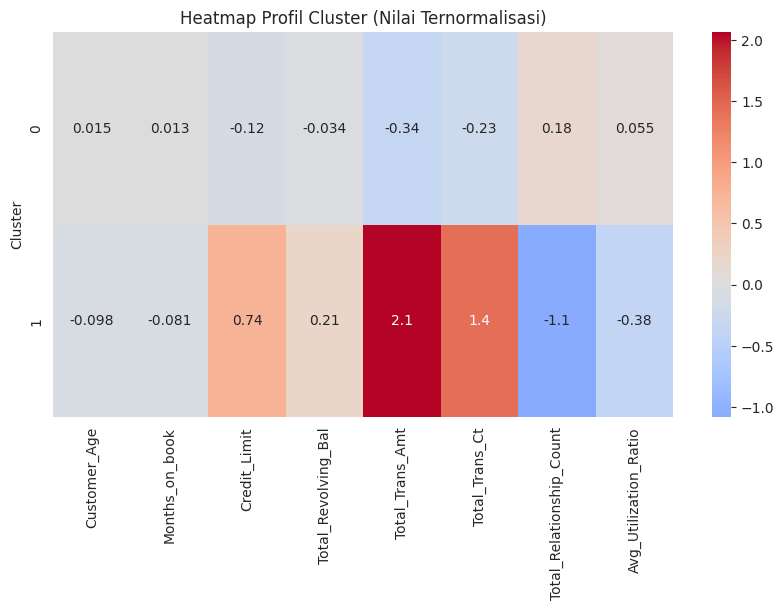

In [ ]:
# Heatmap profil cluster (versi ternormalisasi agar mudah dibandingkan)
profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profile[features]),
    columns=features,
    index=cluster_profile.index
)

plt.figure(figsize=(10, 5))
sns.heatmap(profile_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap Profil Cluster (Nilai Ternormalisasi)")
plt.ylabel("Cluster")
plt.show()


### 5.2 Interpretasi Bisnis Setiap Cluster

Berdasarkan `cluster_profile` dan heatmap di atas, model K-Means dengan **k = 2** menghasilkan dua segmen nasabah dengan karakteristik yang cukup kontras:

**Cluster 0 — "Nasabah Reguler" (8.708 nasabah / 86%)**
- Credit_Limit rata-rata lebih rendah (± 7.533)
- Total_Trans_Amt dan Total_Trans_Ct jauh lebih rendah (± 3.262 / 59 transaksi)
- Avg_Utilization_Ratio lebih tinggi (± 0,29) — proporsi limit yang terpakai lebih besar
- Total_Relationship_Count lebih tinggi (± 4,1 produk) — lebih banyak menggunakan produk bank lain

**Cluster 1 — "Nasabah Premium/High-Spender" (1.419 nasabah / 14%)**
- Credit_Limit jauh lebih tinggi (± 15.374, hampir 2x lipat Cluster 0)
- Total_Trans_Amt dan Total_Trans_Ct jauh lebih tinggi (± 11.414 / 99 transaksi — sekitar 3,5x Cluster 0)
- Avg_Utilization_Ratio lebih rendah (± 0,17) — meski limitnya besar, mereka tidak terlalu bergantung pada limit tersebut
- Total_Relationship_Count sedikit lebih rendah (± 2,1 produk)

Variabel yang **paling membedakan** kedua cluster adalah **Credit_Limit, Total_Trans_Amt, dan Total_Trans_Ct**, sedangkan Customer_Age dan Months_on_book relatif mirip di kedua cluster (bukan pembeda utama).

**Implikasi bisnis:**
- **Cluster 1** adalah segmen nasabah bernilai tinggi (*high-value customer*) dengan transaksi besar namun risiko utilisasi rendah — cocok ditawarkan produk premium, kartu kelas atas, atau program *loyalty* eksklusif.
- **Cluster 0** adalah mayoritas nasabah dengan transaksi lebih kecil namun utilisasi limit lebih tinggi — berpotensi untuk ditawarkan edukasi manajemen kredit, produk cicilan, atau program yang mendorong peningkatan frekuensi transaksi.

### 5.3 Kesimpulan Evaluasi
Silhouette Score yang diperoleh adalah **0,270** dan Davies-Bouldin Index **1,50**. Nilai ini tergolong **cukup (moderate)** — cluster yang terbentuk sudah bisa dibedakan dan diinterpretasikan secara bisnis dengan jelas (terlihat dari perbedaan signifikan pada Credit_Limit dan aktivitas transaksi), meskipun secara matematis belum tergolong sangat optimal karena masih ada tumpang tindih antar cluster (terlihat pada visualisasi PCA yang variansinya baru menjelaskan ±48% dari data asli).

Meski begitu, hasil ini tetap **memenuhi kriteria keberhasilan** pada tahap Business Understanding, karena kedua cluster memiliki profil bisnis yang jelas dan actionable, sehingga model ini layak dilanjutkan ke tahap **Deployment**.

## 6. Deployment

Tahap terakhir adalah menyimpan model (beserta scaler dan daftar fitur) agar dapat digunakan oleh aplikasi **Streamlit** (`app.py`) yang terpisah dari notebook ini. Melalui aplikasi tersebut, pengguna (misalnya staf bank) dapat memasukkan data seorang nasabah baru dan langsung mengetahui nasabah tersebut termasuk ke dalam segmen/cluster yang mana, lengkap dengan interpretasi singkatnya.

Aplikasi Streamlit-nya dijalankan dari file terpisah `app.py` (lihat folder deployment), menggunakan artefak yang disimpan di bawah ini: `kmeans_model.pkl`, `scaler.pkl`, dan `features.json`.


In [ ]:
# Menyimpan model, scaler, dan daftar fitur untuk keperluan deployment (Streamlit)
joblib.dump(kmeans_final, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

with open("features.json", "w") as f:
    json.dump(features, f)

# Menyimpan juga tabel profil cluster agar aplikasi Streamlit bisa menampilkan interpretasi
cluster_profile.to_csv("cluster_profile.csv")

print("Model, scaler, daftar fitur, dan profil cluster berhasil disimpan.")
print("File yang dihasilkan: kmeans_model.pkl, scaler.pkl, features.json, cluster_profile.csv")


Model, scaler, daftar fitur, dan profil cluster berhasil disimpan.
File yang dihasilkan: kmeans_model.pkl, scaler.pkl, features.json, cluster_profile.csv


### Link Deployment
Aplikasi telah di-deploy melalui **Streamlit Community Cloud** dan dapat diakses melalui link berikut:

> **Link Aplikasi:** _(isi dengan link Streamlit Anda setelah proses deployment, contoh: https://nama-app-anda.streamlit.app)_

---
Copyright © 2026 — Tugas Mandiri Pertemuan 4, Data Science Artificial Intelligence Course, Universitas Gunadarma
